In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["TF_CUDNN_USE_AUTOTUNE"] = "0"
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
tf.config.optimizer.set_jit(True)  # Enable XLA

E0000 00:00:1746014297.404108   42444 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746014297.407058   42444 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import pandas as pd
import numpy as np
from glob import glob

In [3]:
from sklearn.model_selection import KFold
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, 
                             hamming_loss, f1_score, roc_auc_score)

from tensorflow.keras import layers, models
from tensorflow.keras import backend as K
from keras.callbacks import LearningRateScheduler, EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay
import gc

from tensorflow.keras.mixed_precision import set_global_policy
policy = tf.keras.mixed_precision.Policy('mixed_float16')
tf.keras.mixed_precision.set_global_policy(policy)
print("Mixed precision enabled with policy:", policy.name)

Mixed precision enabled with policy: mixed_float16


### Helper functions to load the dataset

In [4]:
def get_feature_description():
    feature_description = {
        'mel': tf.io.FixedLenFeature([], tf.string),
        'labels': tf.io.VarLenFeature(tf.int64),
        'song': tf.io.FixedLenFeature([], tf.string),
        'segment_idx': tf.io.FixedLenFeature([], tf.int64),
        'total_segments': tf.io.FixedLenFeature([], tf.int64),
    }
    return feature_description

In [5]:
def get_labels(file):
    dataset = tf.data.TFRecordDataset(file)
    feature_description = {
        'labels': tf.io.VarLenFeature(tf.int64)
    }
    for example in dataset.take(1):
        parsed = tf.io.parse_single_example(example, feature_description)
        labels = tf.sparse.to_dense(parsed['labels']).numpy()
    return labels

In [6]:
def get_song_id(file):
    ds = tf.data.TFRecordDataset(file)
    feat = {'song': tf.io.FixedLenFeature([], tf.string)}
    raw = next(iter(ds))
    parsed = tf.io.parse_single_example(raw, feat)
    return parsed['song'].numpy().decode('utf-8')

In [7]:
def parse_tfrecord_fn(example):
    feature_description = get_feature_description()
    example = tf.io.parse_single_example(example, feature_description)
    
    # Directly parse the float32 tensor
    mel_spec = tf.io.parse_tensor(example['mel'], out_type=tf.float32)
    
    current_shape = tf.shape(mel_spec)
    
    if tf.rank(mel_spec) != 2:
        # If not a 2D tensor, reshape it to [80, ?]
        mel_spec = tf.reshape(mel_spec, [96, -1])
        current_shape = tf.shape(mel_spec)
    
    # Crop or pad the time dimension to mean_axis_time
    if current_shape[1] > mean_axis_time_global:
        # Crop to [80, 650]
        mel_spec = mel_spec[:, :mean_axis_time_global]
    else:
        # Pad to [80, 650]
        paddings = [[0, 0], [0, mean_axis_time_global - current_shape[1]]]
        mel_spec = tf.pad(mel_spec, paddings, "CONSTANT", constant_values=0)
    
    mel_spec = tf.ensure_shape(mel_spec, [96, mean_axis_time_global])

    # normalization
    mel_spec = (mel_spec - mean_global) / (std_global + 1e-6)
    
    # Add channel dimension
    mel_spec = tf.expand_dims(mel_spec, axis=-1)
    
    labels = tf.sparse.to_dense(example['labels'])
    labels = tf.ensure_shape(labels, [8])

    return mel_spec, labels

In [8]:
def prepare_dataset(tfrecord_pattern, batch_size=32, is_training=True):
    
    dataset = tf.data.Dataset.list_files(tfrecord_pattern, shuffle=is_training)

    
    dataset = tf.data.TFRecordDataset(
        dataset, 
        buffer_size=8*1024*1024,
        num_parallel_reads=8
    )
    
    dataset = dataset.map(parse_tfrecord_fn, num_parallel_calls=8)
    #dataset = dataset.cache()  # Cache after parsing but before augmentation
    
    if is_training:
        # Apply enhanced augmentation for training data
        dataset = dataset.map(augment, num_parallel_calls=8)
        dataset = dataset.shuffle(40000)
        
    dataset = dataset.batch(batch_size, drop_remainder=is_training)

    dataset = dataset.map(
        lambda x, y: (x, {'aux_out': y, 'binary_output': y}),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    
    if is_training:
        dataset = dataset.repeat()
    
    dataset = dataset.prefetch(1)
    
    return dataset

### Augmentation functions

In [9]:
def stretch_mel_time_axis(mel, factor_range=(0.9, 1.1)):
    factor = tf.random.uniform([], factor_range[0], factor_range[1])
    time_steps = tf.cast(tf.shape(mel)[1], tf.float32)
    new_time_steps = tf.cast(time_steps * factor, tf.int32)
    mel = tf.image.resize(mel, size=[tf.shape(mel)[0], new_time_steps])
    mel = tf.image.resize_with_crop_or_pad(mel, 80, mean_axis_time_global)
    return mel

In [10]:
def time_mask(x, max_frames=40):
    #zero-out a random consecutive time stripe
    T  = tf.shape(x)[1]
    t  = tf.random.uniform([], 0, max_frames, tf.int32)
    t0 = tf.random.uniform([], 0, T - t,      tf.int32)
    zeros = tf.zeros_like(x[:, t0:t0+t, :])
    return tf.concat([x[:, :t0, :], zeros, x[:, t0+t:, :]], axis=1)

In [11]:
def freq_mask(x, max_bins=16):
    #zero-out a random consecutive mel-bin stripe
    F  = tf.shape(x)[0]
    f  = tf.random.uniform([], 0, max_bins, tf.int32)
    f0 = tf.random.uniform([], 0, F - f,      tf.int32)
    zeros = tf.zeros_like(x[f0:f0+f, :, :])
    return tf.concat([x[:f0, :, :], zeros, x[f0+f:, :, :]], axis=0)

In [12]:
def random_gain(x, min_gain=0.9, max_gain=1.1):
    #small volume-like tweaks
    gain = tf.random.uniform([], min_gain, max_gain)
    return x * gain

In [13]:
def random_time_shift(x, max_shift=10):
    #roll time axis and wrap it around
    shift = tf.random.uniform([], -max_shift, max_shift, dtype=tf.int32)
    return tf.roll(x, shift=shift, axis=1)

In [14]:
def augment(m, labels):
    orig_e = tf.reduce_mean(tf.square(m))
    T = tf.shape(m)[1]

    # — Time Mask —
    def do_time_mask():
        mm = time_mask(m, 80)
        e = tf.reduce_mean(tf.square(mm))
        return mm * tf.sqrt(orig_e / (e + 1e-8))
    m = tf.cond(
        tf.random.uniform([]) < 0.8,
        true_fn=do_time_mask,
        false_fn=lambda: m
    )

    # — Freq Mask —
    def do_freq_mask():
        mm = freq_mask(m, 28)
        e = tf.reduce_mean(tf.square(mm))
        return mm * tf.sqrt(orig_e / (e + 1e-8))
    m = tf.cond(
        tf.random.uniform([]) < 0.8,
        true_fn=do_freq_mask,
        false_fn=lambda: m
    )

    # — Random Gain —
    def do_gain():
        return random_gain(m, 0.85, 1.15)
    m = tf.cond(
        tf.random.uniform([]) < 0.7,
        true_fn=do_gain,
        false_fn=lambda: m
    )

    # — Time Shift —
    m = tf.cond(
        tf.random.uniform([]) < 0.6,
        true_fn=lambda: random_time_shift(m, max_shift=10),
        false_fn=lambda: m
    )

    # — Noise + Renorm —
    def do_noise():
        std = tf.random.uniform([], 0.03/2, 0.03)
        mm = m + tf.random.normal(tf.shape(m), 0., std, dtype=m.dtype)
        e = tf.reduce_mean(tf.square(mm))
        return mm * tf.sqrt(orig_e / (e + 1e-8))
    m = tf.cond(
        tf.random.uniform([]) < 1.0,
        true_fn=do_noise,
        false_fn=lambda: m
    )

    # — Time Crop + Renorm + Pad —
    def do_crop():
        win = tf.random.uniform([], T - 80, T, dtype=tf.int32)
        start = tf.random.uniform([], 0, T - win, dtype=tf.int32)
        cm = m[:, start:start + win, :]
        e = tf.reduce_mean(tf.square(cm))
        cm = cm * tf.sqrt(orig_e / (e + 1e-8))
        return tf.pad(cm, [[0,0], [0, T - win], [0,0]])
    m = tf.cond(
        tf.random.uniform([]) < 0.45,
        true_fn=do_crop,
        false_fn=lambda: m
    )

    # ensure shape
    m = tf.ensure_shape(m, [96, mean_axis_time_global, 1])
    return m, labels

### Model Architecture

In [15]:
def residual_block(x, filters, kernel_size=3, stride=1, activation='relu', use_dropout=False, regularization=1e-7):
    shortcut = x
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same', 
                      kernel_initializer='he_normal',
                     kernel_regularizer=tf.keras.regularizers.l2(regularization))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    
    if use_dropout:
        x = layers.Dropout(0.2)(x)
    
    x = layers.Conv2D(filters, kernel_size, strides=1, padding='same', 
                      kernel_initializer='he_normal',
                     kernel_regularizer=tf.keras.regularizers.l2(regularization))(x)
    x = layers.BatchNormalization()(x)
    
    # Adaptive shortcut connection
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', 
                                 kernel_initializer='he_normal')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
    x = layers.Add()([shortcut, x])
    x = layers.Activation(activation)(x)
    return x
def attention_layer(x):
    # Channel-wise attention
    channel_mean = layers.GlobalAveragePooling2D()(x)
    channel_max = layers.GlobalMaxPooling2D()(x)
    
    # Compact attention mechanism
    attention_features = layers.Dense(x.shape[-1] // 4, activation='relu')(channel_mean)
    attention_features = layers.Dense(x.shape[-1], activation='sigmoid')(attention_features)
    
    # Spatial attention component
    spatial_attention = layers.Conv2D(1, 7, padding='same', activation='sigmoid')(
        layers.Concatenate()([
            layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(x),
            layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(x)
        ])
    )
    
    # Apply attention
    x = layers.Multiply()([x, attention_features[:, tf.newaxis, tf.newaxis, :]])
    x = layers.Multiply()([x, spatial_attention])
    
    return x

In [16]:
from tensorflow.keras.callbacks import Callback

class AuxLossDisabler(Callback):
    def __init__(self, epoch_to_disable=20):
        super().__init__()
        self.epoch_to_disable = epoch_to_disable

    def on_epoch_begin(self, epoch, logs=None):
        if epoch == self.epoch_to_disable:
            print(f"\nEpoch {epoch}: Disabling aux_out loss.")
            self.model.loss_weights = {"aux_out": 0.0, "binary_output": 1.0}

In [17]:
def model_CNN(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    
    x = layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    
    x = layers.MaxPooling2D((2, 4))(x)
    
    x = residual_block(x, 64, use_dropout=True, regularization=1e-6)
    x = layers.MaxPooling2D((2, 3))(x)

    x = residual_block(x, 96, stride=2, regularization=1e-5)
    x = layers.Dropout(0.25)(x)

    aux = layers.GlobalAveragePooling2D()(x)
    aux = layers.Dense(128, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.0005))(aux)
    aux = layers.Dropout(0.25)(aux)
    aux_out = layers.Dense(8, activation='sigmoid', name='aux_out')(aux)
    
    x = residual_block(x, 128, stride=2)
    x = layers.Dropout(0.3)(x)
    
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dense(512, kernel_regularizer=tf.keras.regularizers.l2(0.0005), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.45)(x)

    x = layers.Dense(128, activation='gelu', 
                     kernel_regularizer=tf.keras.regularizers.l2(0.0003))(x)
    x = layers.Dropout(0.15)(x)

    binary_out = layers.Dense(8, activation='sigmoid',
                        kernel_initializer='he_normal',
                        kernel_regularizer=tf.keras.regularizers.l2(1e-5),
                        name='binary_output')(x)
    
    return models.Model(inputs, outputs=[aux_out, binary_out])

In [18]:
def model_CNN_Att(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    
    x = layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(0.2)(x)
    
    x = layers.MaxPooling2D((2, 4))(x)
    
    x = residual_block(x, 64, use_dropout=True, regularization=1e-5)
    x = layers.MaxPooling2D((2, 3))(x)

    x = residual_block(x, 96, stride=2, regularization=1e-5)
    x = layers.Dropout(0.25)(x)

    aux = layers.GlobalAveragePooling2D()(x)
    aux = layers.Dense(128, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.0005))(aux)
    aux = layers.Dropout(0.25)(aux)
    aux_out = layers.Dense(8, activation='sigmoid', name='aux_out')(aux)
    
    x = residual_block(x, 128, stride=2)
    x = attention_layer(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dense(512, kernel_regularizer=tf.keras.regularizers.l2(0.0005), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.45)(x)

    x = layers.Dense(128, activation='gelu', 
                     kernel_regularizer=tf.keras.regularizers.l2(0.0003))(x)
    x = layers.Dropout(0.15)(x)

    binary_out = layers.Dense(8, activation='sigmoid',
                        kernel_initializer='he_normal',
                        kernel_regularizer=tf.keras.regularizers.l2(1e-5),
                        name='binary_output')(x)
    
    return models.Model(inputs, outputs=[aux_out, binary_out])

#### Custom error functions 

In [19]:
#start with aux loss weight 0.3 then decrease it to minimum 0.05
class DynamicLossWeightDecay(tf.keras.callbacks.Callback):
    def __init__(self, initial_aux_weight=0.3, decay_rate=0.9, min_aux_weight=0.05):
        self.initial_aux_weight = initial_aux_weight
        self.decay_rate = decay_rate
        self.min_aux_weight = min_aux_weight
        self.current_aux_weight = initial_aux_weight

    def on_epoch_end(self, epoch, logs=None):
        # Decay the aux weight
        self.current_aux_weight = max(self.min_aux_weight, self.current_aux_weight * self.decay_rate)

        # Update model's loss weights
        self.model.loss_weights = {
            'binary_output': 1.0,
            'aux_out': self.current_aux_weight
        }

In [20]:
@tf.function
def custom_cosine_similarity(y_true, y_pred):
    dot_product = tf.reduce_sum(y_true * y_pred, axis=-1)
    norm_true = tf.sqrt(tf.reduce_sum(y_true ** 2, axis=-1))
    norm_pred = tf.sqrt(tf.reduce_sum(y_pred ** 2, axis=-1))
    # If norm_pred is too small, set similarity to 0 to avoid NaN
    cosine_sim = tf.where(norm_pred > 1e-8, dot_product / (norm_true * norm_pred + 1e-8), 0.0)
    return 1.0 -cosine_sim  # minimize loss

In [21]:
@tf.function
def focal_sparsity_entropy_loss(
    y_true, y_pred_logits, gamma=3.0, class_weights=None, 
    sparsity_weight=0.01, entropy_weight=0.005, target_mean_activation=0.2
):
    dtype = y_pred_logits.dtype
    y_true = tf.cast(y_true, dtype=dtype)
    
    # Create smoothed version only for BCE loss calculation
    smooth_factor = 0.1
    y_true_smoothed = y_true * (1 - smooth_factor) + smooth_factor * 0.05
    
    y_pred_logits = tf.clip_by_value(y_pred_logits, -5, 5)
    y_pred = tf.nn.sigmoid(y_pred_logits)
    
    # Use smoothed labels only for BCE loss
    bce = tf.nn.sigmoid_cross_entropy_with_logits(labels=y_true_smoothed, logits=y_pred_logits)
    
    # Use original labels for focal weighting
    p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
    focal_weight = tf.pow(1 - p_t, gamma)
    focal_bce = focal_weight * bce
    
    if class_weights is not None:
        weights_0 = tf.cast(class_weights[:, 0][None, :], dtype=dtype)
        weights_1 = tf.cast(class_weights[:, 1][None, :], dtype=dtype)
        # Use original labels for weight assignment
        weights = tf.where(y_true == 1.0, weights_1, weights_0)
        focal_bce = focal_bce * weights
        
    focal_loss = tf.reduce_mean(focal_bce, axis=-1)
    
    # Penalize too few activations (discourage overconfident zeros)
    mean_activation = tf.reduce_mean(y_pred, axis=-1)
    sparsity_penalty = tf.square(mean_activation - target_mean_activation)
    
    # Penalize high-entropy (uncertain) predictions
    p = tf.clip_by_value(y_pred, 1e-6, 1. - 1e-6)
    entropy = -p * tf.math.log(p) - (1 - p) * tf.math.log(1 - p)
    entropy_penalty = tf.reduce_mean(entropy, axis=-1)
    
    return focal_loss + sparsity_weight * sparsity_penalty + entropy_weight * entropy_penalty

In [22]:
from sklearn.model_selection import train_test_split
from collections import Counter

In [23]:
import utils_glob_stats

# Load global statistics with utils
label_frequencies = utils_glob_stats.load_class_weights(segment_length=10)

global_stats = utils_glob_stats.load_global_stats(segment_length=10)

time_axis_stats = utils_glob_stats.load_time_axis_stats(segment_length=10)

I0000 00:00:1746014299.021486   42444 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5520 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [24]:
total = label_frequencies['total_examples']
class_weights_combined = label_frequencies['combined_weights_numpy']
class_weights_tf = tf.constant(class_weights_combined, dtype=tf.float32) #convert to tensor for focal loss

mean_global = global_stats['mean']
std_global = global_stats['std']

mean_axis_time_global = time_axis_stats['mean']

print('Total training examples, ', total)
print('Spectrogram mean, ', mean_global)
print('Spectrogram std, ', std_global)
print('Mean time axis val, ', mean_axis_time_global)
print('Class weights, ', class_weights_combined)

Total training examples,  70078
Spectrogram mean,  -38.622053581065884
Spectrogram std,  13.92796650578306
Mean time axis val,  432
Class weights,  [[0.19714070306078363, 0.34159062547412294], [0.14197785989591272, 1.0453162289922056], [0.1832123734588971, 0.3934137249441564], [0.1594014994329912, 0.5791953186604605], [0.18091928621213352, 0.4044205909323905], [0.14573351300749096, 0.878610832409367], [0.1613689116468689, 0.554625174081637], [0.1319795998292657, 2.3636670258058103]]


In [25]:
files_dir = tf.io.gfile.glob(
    "/home/georgios/Music Analysis/dataset_creation/tfrecord_dataset_10s/train/*.tfrecord"
)
labels = np.array([get_labels(f) for f in files_dir])
all_files = np.array(files_dir)

In [26]:
song_ids = [get_song_id(f) for f in all_files]

In [27]:
# map song_id to indices
song_to_idxs = {}
for i, sid in enumerate(song_ids):
    song_to_idxs.setdefault(sid, []).append(i)

In [28]:
# compute initial val_indices by label coverage
n_total = len(all_files)
val_split = 0.10
n_each = int(n_total * (val_split/2))

In [29]:
start = np.arange(n_each)
end   = np.arange(n_total-n_each, n_total)
val_set = set(np.concatenate([start, end]))

In [30]:
for g in range(labels.shape[1]):
    vl = labels[list(val_set)]
    if vl[:,g].sum() == 0:
        for i in range(n_total):
            if i not in val_set and labels[i, g] == 1:
                val_set.add(i)
                break

In [31]:
# expand to include all segments of each chosen song
expanded = set()
for i in val_set:
    sid = song_ids[i]
    expanded.update(song_to_idxs[sid])

In [32]:
val_indices = np.array(sorted(expanded))
train_indices = np.array([i for i in range(n_total) if i not in val_indices])

In [33]:
# final splits
train_files = all_files[train_indices]
val_files   = all_files[val_indices]

print("Train samples:", len(train_files))
print("Val   samples:", len(val_files))

Train samples: 63
Val   samples: 8


In [34]:
class_weights_np = class_weights_tf.numpy() # Convert tf.Tensor to NumPy

# Double weights for POP (index 5) and ENALLAKTIKO (index 6) positive class (column 1)
class_weights_np[5, 1] *= 4.0  # POP
class_weights_np[6, 1] *= 4.0  # ENALLAKTIKO

# Convert back to tf.Tensor
class_weights_tf = tf.constant(class_weights_np, dtype=tf.float32)

print(class_weights_tf)

tf.Tensor(
[[0.19714071 0.3415906 ]
 [0.14197786 1.0453162 ]
 [0.18321237 0.39341372]
 [0.1594015  0.5791953 ]
 [0.18091929 0.40442058]
 [0.14573352 3.5144434 ]
 [0.1613689  2.2185006 ]
 [0.1319796  2.363667  ]], shape=(8, 2), dtype=float32)


In [35]:
batch_size = 64

In [36]:
train_dataset = prepare_dataset(train_files, batch_size= batch_size)

In [37]:
val_dataset = prepare_dataset(val_files, batch_size=64, is_training=False)

In [38]:
examples_per_file = total / len(train_files)

orig_files_count = len(train_files)

estimated_total_examples = orig_files_count * examples_per_file
steps_per_epoch = int(estimated_total_examples // batch_size if estimated_total_examples
                      % batch_size == 0 else (estimated_total_examples // batch_size) + 1)
print(f"Total training examples: {total}")
print(f"Original files: {orig_files_count}")
print(f"Steps per epoch: {steps_per_epoch:.0f}")

Total training examples: 70078
Original files: 63
Steps per epoch: 1095


In [39]:
@tf.function
def focal_sparsity_entropy_loss_with_weights(y_true, y_pred):
    return focal_sparsity_entropy_loss(
        y_true, y_pred,
        gamma=1.0,
        class_weights=class_weights_tf,
        sparsity_weight=0.02,
        entropy_weight=0.002,
        target_mean_activation=0.2
    )

In [40]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0)
lr_scheduler = CosineDecay(initial_learning_rate=1e-4, decay_steps=33300)

In [41]:
model_cnn = model_CNN(input_shape=(96, mean_axis_time_global, 1), num_classes=8)

In [42]:
save_path = 'saved_models/best_CNN_model.keras'

In [43]:
# Compile the model with the modified loss function
model_cnn.compile(
    optimizer=optimizer,
    loss={'binary_output': focal_sparsity_entropy_loss_with_weights,
         'aux_out': custom_cosine_similarity},
    loss_weights={'binary_output': 1.0, 'aux_out':0.4},
    metrics={'binary_output': [
            tf.keras.metrics.BinaryAccuracy(),
            tf.keras.metrics.F1Score(threshold=0.5, average='micro', name='f1_micro'),
            tf.keras.metrics.F1Score(threshold=0.5, average='macro', name='f1_macro')]}
)

In [44]:
model_cnn.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 432,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 96, 432,   │          0 │ input_layer[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 96, 432,   │        288 │ cast[0][0]        │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 96, 432,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 96, 432,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 48, 108,   │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 48, 108,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 108,   │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 48, 108,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 48, 108,   │          0 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 48, 108,   │      2,112 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 48, 108,   │     36,928 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 108,   │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 108,   │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 48, 108,   │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 48, 108,   │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 24, 36,    │          0 │ activation_2[0][

 Total params: 624,528 (2.38 MB)

 Trainable params: 621,712 (2.37 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [45]:
callbacks = [
    AuxLossDisabler(epoch_to_disable=20),
    DynamicLossWeightDecay(initial_aux_weight=0.3, decay_rate=0.9, min_aux_weight=0.05),
    EarlyStopping(
        monitor='val_binary_output_f1_macro',
        patience=5,
        restore_best_weights=True,
        mode = 'max',
        verbose=1
    ),
    ModelCheckpoint(
        filepath=save_path,
        monitor='val_binary_output_f1_macro',
        mode = 'max',
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)]

In [46]:
# Train the model
history = model_cnn.fit(
    train_dataset, 
    epochs=20,
    callbacks= callbacks,
    steps_per_epoch = steps_per_epoch,
    validation_data = val_dataset
)

Epoch 1/20


I0000 00:00:1746000104.462524   75757 service.cc:148] XLA service 0x7f52680030e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746000104.462554   75757 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
I0000 00:00:1746000104.468414   75757 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1746000104.497161   75757 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1094/1095 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - aux_out_loss: 0.3621 - binary_output_binary_accuracy: 0.7370 - binary_output_f1_macro: 0.4234 - binary_output_f1_micro: 0.4320 - binary_output_loss: 0.1015 - loss: 0.3078 
Epoch 1: val_binary_output_f1_macro improved from -inf to 0.50275, saving model to saved_models/best_CNN_model.keras


/home/georgios/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1095/1095 ━━━━━━━━━━━━━━━━━━━━ 80s 47ms/step - aux_out_loss: 0.3620 - binary_output_binary_accuracy: 0.7370 - binary_output_f1_macro: 0.4235 - binary_output_f1_micro: 0.4321 - binary_output_loss: 0.1015 - loss: 0.3077 - val_aux_out_loss: 0.3544 - val_binary_output_binary_accuracy: 0.7669 - val_binary_output_f1_macro: 0.5028 - val_binary_output_f1_micro: 0.4918 - val_binary_output_loss: 0.1013 - val_loss: 0.2549 - learning_rate: 0.0010
Epoch 2/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - aux_out_loss: 0.2725 - binary_output_binary_accuracy: 0.7973 - binary_output_f1_macro: 0.5725 - binary_output_f1_micro: 0.5649 - binary_output_loss: 0.0940 - loss: 0.2142 
Epoch 2: val_binary_output_f1_macro improved from 0.50275 to 0.51847, saving model to saved_models/best_CNN_model.keras
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 52s 48ms/step - aux_out_loss: 0.2725 - binary_output_binary_accuracy: 0.7973 - binary_output_f1_macro: 0.5725 - binary_output_f1_micro: 0.5649 - binary_output_loss: 0.0940 - loss: 0

In [52]:
save_path = 'saved_models/best_CNN_Att_model.keras'
model_att = model_CNN_Att(input_shape=(96, mean_axis_time_global, 1), num_classes=8)

In [53]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0)
lr_scheduler = CosineDecay(initial_learning_rate=1e-4, decay_steps=33300)

In [54]:
callbacks = [
    AuxLossDisabler(epoch_to_disable=20),
    DynamicLossWeightDecay(initial_aux_weight=0.3, decay_rate=0.9, min_aux_weight=0.05),
    EarlyStopping(
        monitor='val_binary_output_f1_macro',
        patience=5,
        restore_best_weights=True,
        mode = 'max',
        verbose=1
    ),
    ModelCheckpoint(
        filepath=save_path,
        monitor='val_binary_output_f1_macro',
        mode = 'max',
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)]

In [58]:
# Compile the model with the modified loss function
model_att.compile(
    optimizer=optimizer,
    loss={'binary_output': focal_sparsity_entropy_loss_with_weights,
         'aux_out': custom_cosine_similarity},
    loss_weights={'binary_output': 1.0, 'aux_out':0.4},
    metrics={'binary_output': [
            tf.keras.metrics.BinaryAccuracy(),
            tf.keras.metrics.F1Score(threshold=0.5, average='micro', name='f1_micro'),
            tf.keras.metrics.F1Score(threshold=0.5, average='macro', name='f1_macro')]}
)

In [59]:
# Train the model
history_att = model_att.fit(
    train_dataset, 
    epochs=20,
    callbacks= callbacks,
    steps_per_epoch = steps_per_epoch,
    validation_data = val_dataset
)

Epoch 1/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - aux_out_loss: 0.3636 - binary_output_binary_accuracy: 0.7435 - binary_output_f1_macro: 0.4186 - binary_output_f1_micro: 0.4264 - binary_output_loss: 0.1006 - loss: 0.3081  
Epoch 1: val_binary_output_f1_macro improved from -inf to 0.47155, saving model to saved_models/best_CNN_Att_model.keras
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 89s 55ms/step - aux_out_loss: 0.3635 - binary_output_binary_accuracy: 0.7436 - binary_output_f1_macro: 0.4187 - binary_output_f1_micro: 0.4264 - binary_output_loss: 0.1006 - loss: 0.3081 - val_aux_out_loss: 0.3881 - val_binary_output_binary_accuracy: 0.7657 - val_binary_output_f1_macro: 0.4715 - val_binary_output_f1_micro: 0.4664 - val_binary_output_loss: 0.1028 - val_loss: 0.2722 - learning_rate: 0.0010
Epoch 2/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - aux_out_loss: 0.2740 - binary_output_binary_accuracy: 0.7992 - binary_output_f1_macro: 0.5799 - binary_output_f1_micro: 0.5689 - binary_output_loss: 0.09

### History plots

In [60]:
import matplotlib.pyplot as plt

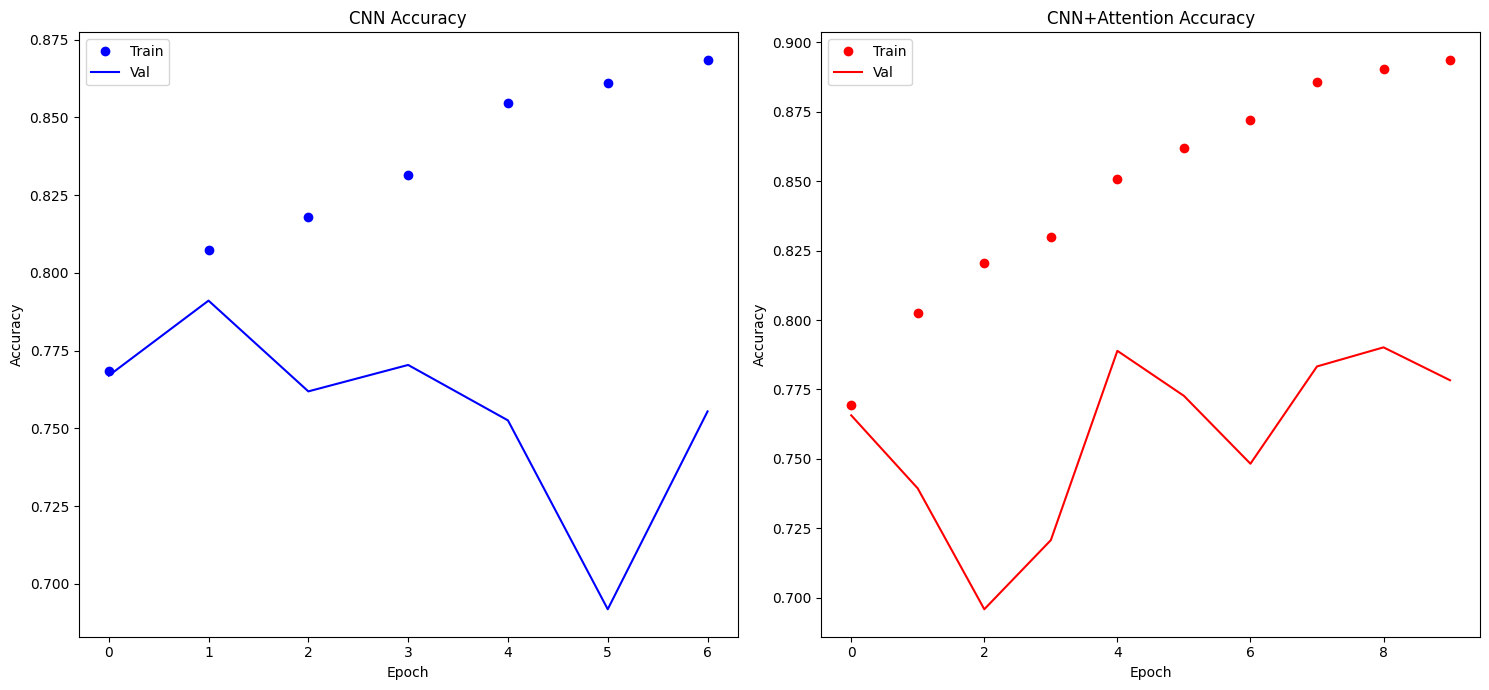

In [61]:
# accuracy comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# CNN
ax1.plot(history.history['binary_output_binary_accuracy'], 'bo', label='Train')
ax1.plot(history.history['val_binary_output_binary_accuracy'], 'b', label='Val')
ax1.set_title('CNN Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# CNN + Attention
ax2.plot(history_att.history['binary_output_binary_accuracy'], 'ro', label='Train')
ax2.plot(history_att.history['val_binary_output_binary_accuracy'], 'r', label='Val')
ax2.set_title('CNN+Attention Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

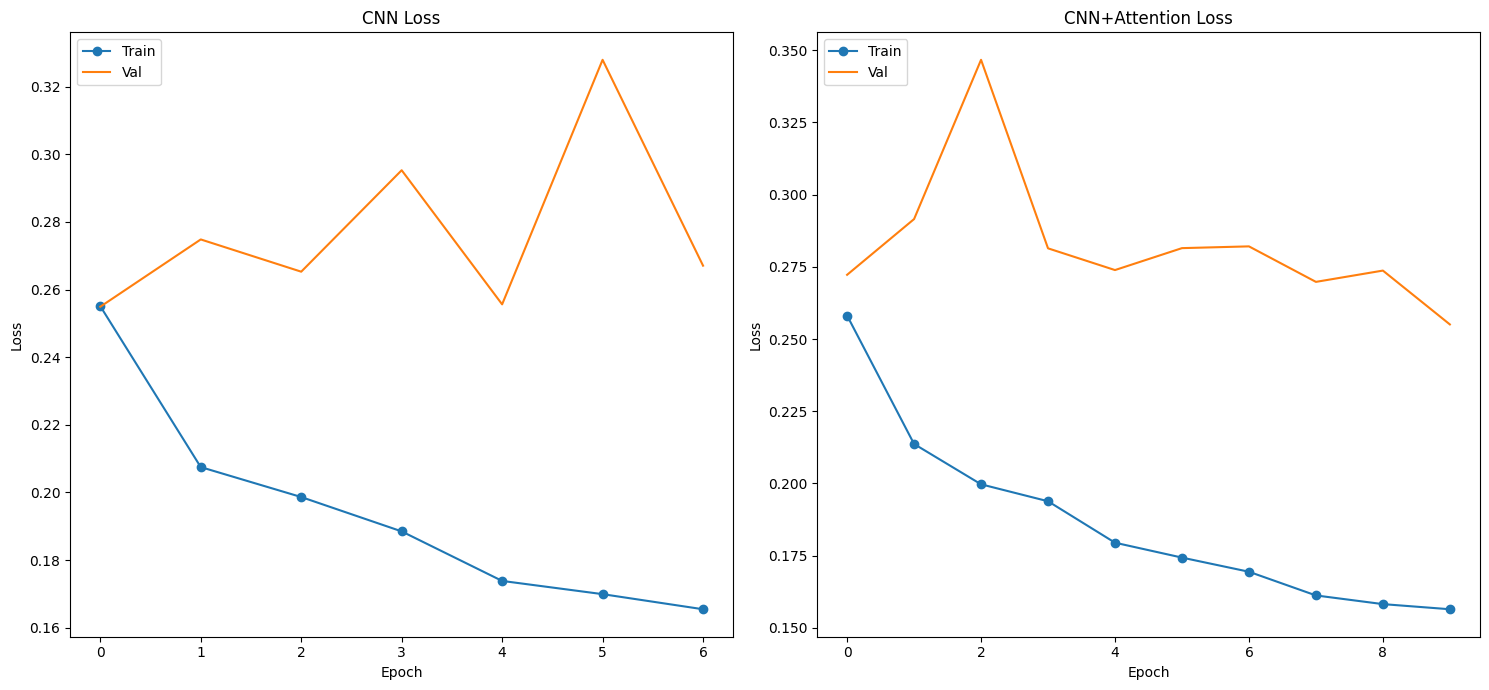

In [62]:
# loss comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

ax1.plot(history.history['loss'], marker='o')
ax1.plot(history.history['val_loss'])
ax1.set_title('CNN Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(['Train', 'Val'], loc='upper left')

ax2.plot(history_att.history['loss'], marker='o')
ax2.plot(history_att.history['val_loss'])
ax2.set_title('CNN+Attention Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(['Train', 'Val'], loc='upper left')

plt.tight_layout()
plt.show()

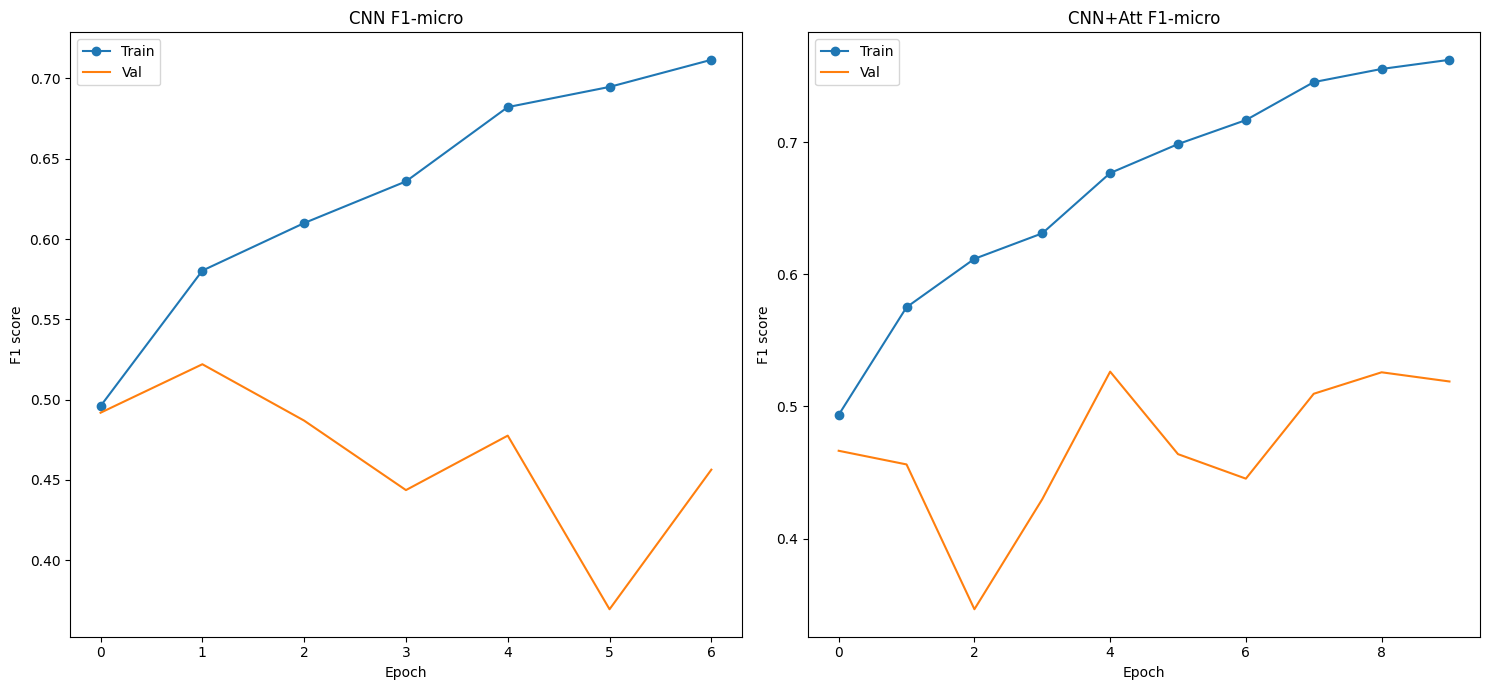

In [63]:
# f1-micro comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

ax1.plot(history.history['binary_output_f1_micro'], marker='o')
ax1.plot(history.history['val_binary_output_f1_micro'])
ax1.set_title('CNN F1-micro')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('F1 score')
ax1.legend(['Train', 'Val'], loc='upper left')

ax2.plot(history_att.history['binary_output_f1_micro'], marker='o')
ax2.plot(history_att.history['val_binary_output_f1_micro'])
ax2.set_title('CNN+Att F1-micro')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 score')
ax2.legend(['Train', 'Val'], loc='upper left')

plt.tight_layout()
plt.show()

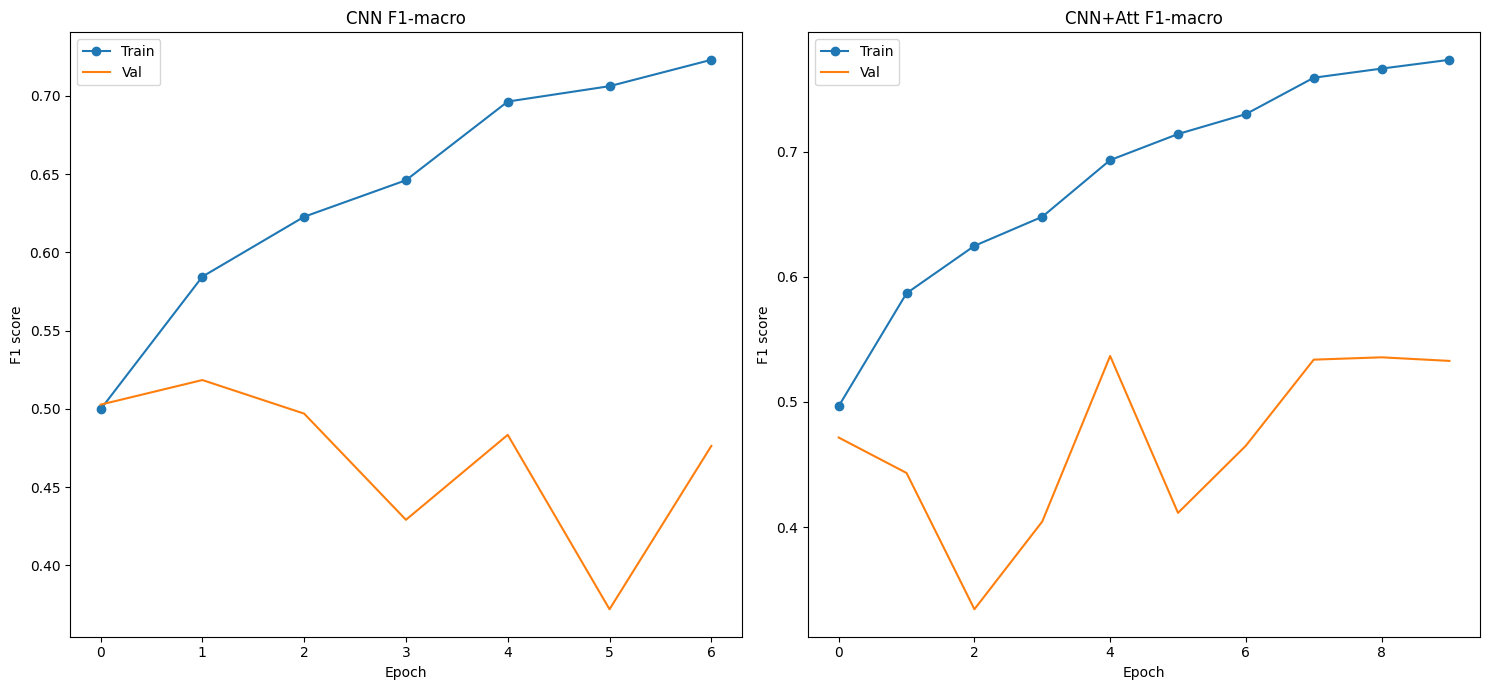

In [64]:
# f1-macro comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

ax1.plot(history.history['binary_output_f1_macro'], marker='o')
ax1.plot(history.history['val_binary_output_f1_macro'])
ax1.set_title('CNN F1-macro')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('F1 score')
ax1.legend(['Train', 'Val'], loc='upper left')

ax2.plot(history_att.history['binary_output_f1_macro'], marker='o')
ax2.plot(history_att.history['val_binary_output_f1_macro'])
ax2.set_title('CNN+Att F1-macro')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 score')
ax2.legend(['Train', 'Val'], loc='upper left')

plt.tight_layout()
plt.show()


### Testing the model

In [41]:
model = model_CNN_Att(input_shape=(96, mean_axis_time_global, 1), num_classes=8)

In [42]:
model.load_weights("saved_models/best_CNN_Att_model.keras")

In [43]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 432,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 96, 432,   │          0 │ input_layer[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 96, 432,   │        288 │ cast[0][0]        │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 96, 432,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 96, 432,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 96, 432,   │          0 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 48, 108,   │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 48, 108,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 108,   │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 48, 108,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 48, 108,   │          0 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 48, 108,   │      2,112 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 48, 108,   │     36,928 │ dropout_1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 108,   │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 108,   │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 48, 108,   │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 48, 108,   │          0 │ add[0][0]       

 Total params: 632,979 (2.41 MB)

 Trainable params: 630,163 (2.40 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [44]:
# Compile the model with the modified loss function
model.compile(
    optimizer=optimizer,
    loss={'binary_output': focal_sparsity_entropy_loss_with_weights,
         'aux_out': custom_cosine_similarity},
    loss_weights={'binary_output': 1.0, 'aux_out':0.3},
    metrics={'binary_output': [
            tf.keras.metrics.BinaryAccuracy(),
            tf.keras.metrics.F1Score(threshold=0.5, average='micro', name='f1_micro'),
            tf.keras.metrics.F1Score(threshold=0.5, average='macro', name='f1_macro')]}
)

In [45]:
# Prepare test dataset
test_files = tf.io.gfile.glob("/home/georgios/Music Analysis/dataset_creation/tfrecord_dataset_10s/test/*.tfrecord")
test_files = np.array(test_files)
test_dataset = prepare_dataset(test_files, batch_size= batch_size, is_training=False)

In [47]:
# Evaluate the model on test data
print("Evaluating model on test data...")
evaluation = model.evaluate(test_dataset)

Evaluating model on test data...


I0000 00:00:1746014330.112216   42576 service.cc:148] XLA service 0x7efa0c002d90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746014330.113486   42576 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
I0000 00:00:1746014330.307937   42576 cuda_dnn.cc:529] Loaded cuDNN version 90300


     21/Unknown 6s 8ms/step - aux_out_loss: 0.3571 - binary_output_binary_accuracy: 0.8217 - binary_output_f1_macro: 0.5190 - binary_output_f1_micro: 0.6131 - binary_output_loss: 0.0958 - loss: 0.2151

I0000 00:00:1746014334.749402   42576 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


101/101 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - aux_out_loss: 0.3563 - binary_output_binary_accuracy: 0.8150 - binary_output_f1_macro: 0.5294 - binary_output_f1_micro: 0.5824 - binary_output_loss: 0.0951 - loss: 0.2142


/home/georgios/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [100]:
# Print overall evaluation metrics
metric_names = ['loss',  
                'binary_accuracy', 'micro', 
                'macro']
for i, metric in enumerate(metric_names):
    print(f"{metric}: {evaluation[i]}")

loss: 0.17795290052890778
binary_accuracy: 0.3163008391857147
micro: 0.07215046882629395
macro: 0.8303167223930359


In [54]:
all_true_labels = []
all_pred_binary = []
all_pred_proba = []

for x_batch, y_batch in test_dataset:
    # Get raw probabilities
    _, y_pred = model.predict(x_batch, verbose=0)
    # Binary predictions
    y_pred_bin = (y_pred > 0.5).astype(np.float32)
    # True labels
    y_true = y_batch['binary_output'].numpy()
    
    all_true_labels.append(y_true)
    all_pred_binary.append(y_pred_bin)
    all_pred_proba.append(y_pred)

In [55]:
y_true = np.vstack(all_true_labels)
y_pred = np.vstack(all_pred_binary)
y_proba = np.vstack(all_pred_proba)

genre_names = ['LAIKO', 'REMPETIKO', 'ENTEXNO', 'ROCK', 'Mod LAIKO', 'POP', 'ENALLAKTIKO', 'HIPHOP/RNB']

print("\nPer-genre evaluation metrics:")
print("Genre\t\tF1\tPrecision\tRecall\tAccuracy\tAUC")
print("-" * 70)

for i, genre in enumerate(genre_names):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true[:, i], y_pred[:, i], average='binary')
    accuracy = accuracy_score(y_true[:, i], y_pred[:, i])
    auc = roc_auc_score(y_true[:, i], y_proba[:, i])
    
    genre_padded = genre + (" " * (15 - len(genre)))
    print(f"{genre_padded}\t{f1:.3f}\t{precision:.3f}\t\t{recall:.3f}\t{accuracy:.3f}\t\t{auc:.3f}")


Per-genre evaluation metrics:
Genre		F1	Precision	Recall	Accuracy	AUC
----------------------------------------------------------------------
LAIKO          	0.755	0.689		0.836	0.806		0.887
REMPETIKO      	0.639	0.511		0.854	0.893		0.947
ENTEXNO        	0.499	0.586		0.434	0.728		0.752
ROCK           	0.623	0.505		0.815	0.819		0.906
Mod LAIKO      	0.403	0.812		0.268	0.744		0.809
POP            	0.420	0.385		0.461	0.829		0.803
ENALLAKTIKO    	0.502	0.368		0.788	0.679		0.765
HIPHOP/RNB     	0.387	0.715		0.265	0.956		0.808


In [56]:
# Calculate overall metrics
print("\nOverall metrics:")
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    y_true.flatten(), y_pred.flatten(), average='binary')
overall_accuracy = accuracy_score(y_true.flatten(), y_pred.flatten())
overall_hamming = hamming_loss(y_true, y_pred)

print(f"Overall F1 Score: {overall_f1:.3f}")
print(f"Overall Precision: {overall_precision:.3f}")
print(f"Overall Recall: {overall_recall:.3f}")
print(f"Overall Accuracy: {overall_accuracy:.3f}")
print(f"Hamming Loss: {overall_hamming:.3f}")


Overall metrics:
Overall F1 Score: 0.565
Overall Precision: 0.535
Overall Recall: 0.597
Overall Accuracy: 0.807
Hamming Loss: 0.193


In [57]:
# Calculate exact match ratio (all genres predicted correctly)
exact_matches = np.all(y_true == y_pred, axis=1).mean()
print(f"Exact Match Ratio: {exact_matches:.3f}")

Exact Match Ratio: 0.198


In [58]:
# Confusion matrix for multi-label classification
print("\nLabel correlation analysis:")
print("Analyzing how well the model captures label relationships...")

# correlation matrices for true labels and predictions
true_corr = np.corrcoef(y_true.T)
pred_corr = np.corrcoef(y_pred.T)

# mean absolute error between correlation matrices
corr_mae = np.abs(true_corr - pred_corr).mean()
print(f"Correlation Matrix MAE: {corr_mae:.3f}")


Label correlation analysis:
Analyzing how well the model captures label relationships...
Correlation Matrix MAE: 0.116


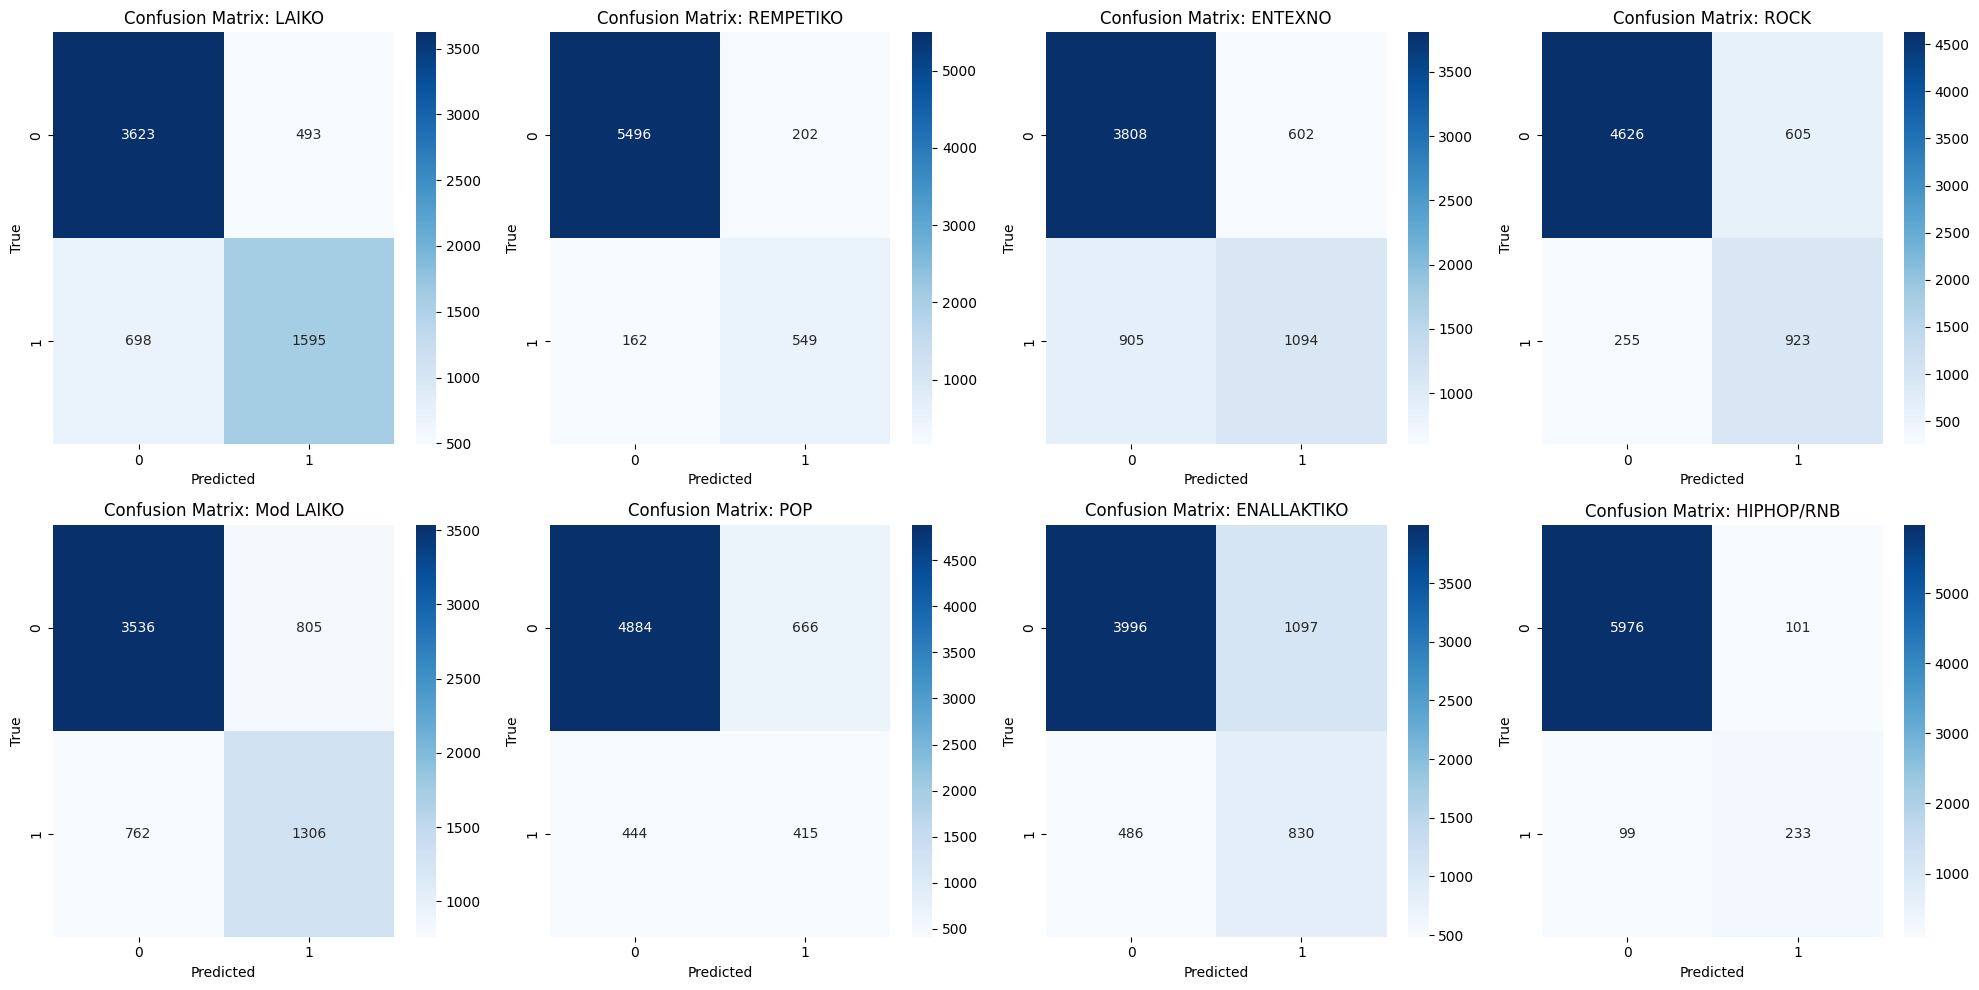

In [55]:
# Visualize results
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Plot confusion matrix for each genre
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
cms = []

for i, (genre, ax) in enumerate(zip(genre_names, axes)):
    cm = confusion_matrix(y_true[:, i], y_pred[:, i])
    cms.append(cm)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix: {genre}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    
plt.tight_layout()
plt.show();

In [56]:
y_true.shape

(6409, 8)

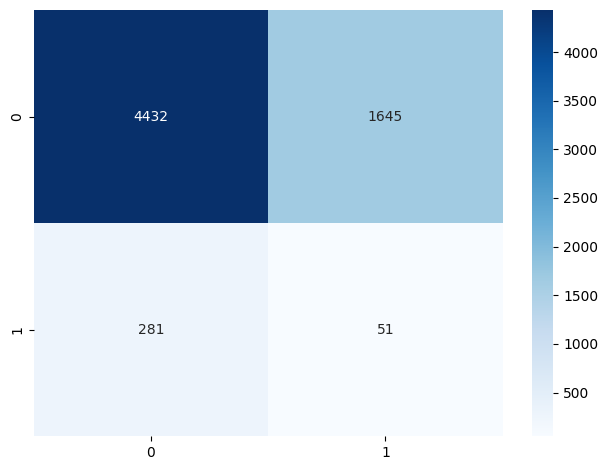

In [57]:
cm = tf.math.confusion_matrix(y_true[:,7], y_pred[:,2])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
ax.set_title(f'Confusion Matrix: {genre}')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout() 
plt.show();

In [58]:
for cm in cms:
    print(cm)

[[3623  493]
 [ 698 1595]]
[[5496  202]
 [ 162  549]]
[[3808  602]
 [ 905 1094]]
[[4626  605]
 [ 255  923]]
[[3536  805]
 [ 762 1306]]
[[4884  666]
 [ 444  415]]
[[3996 1097]
 [ 486  830]]
[[5976  101]
 [  99  233]]


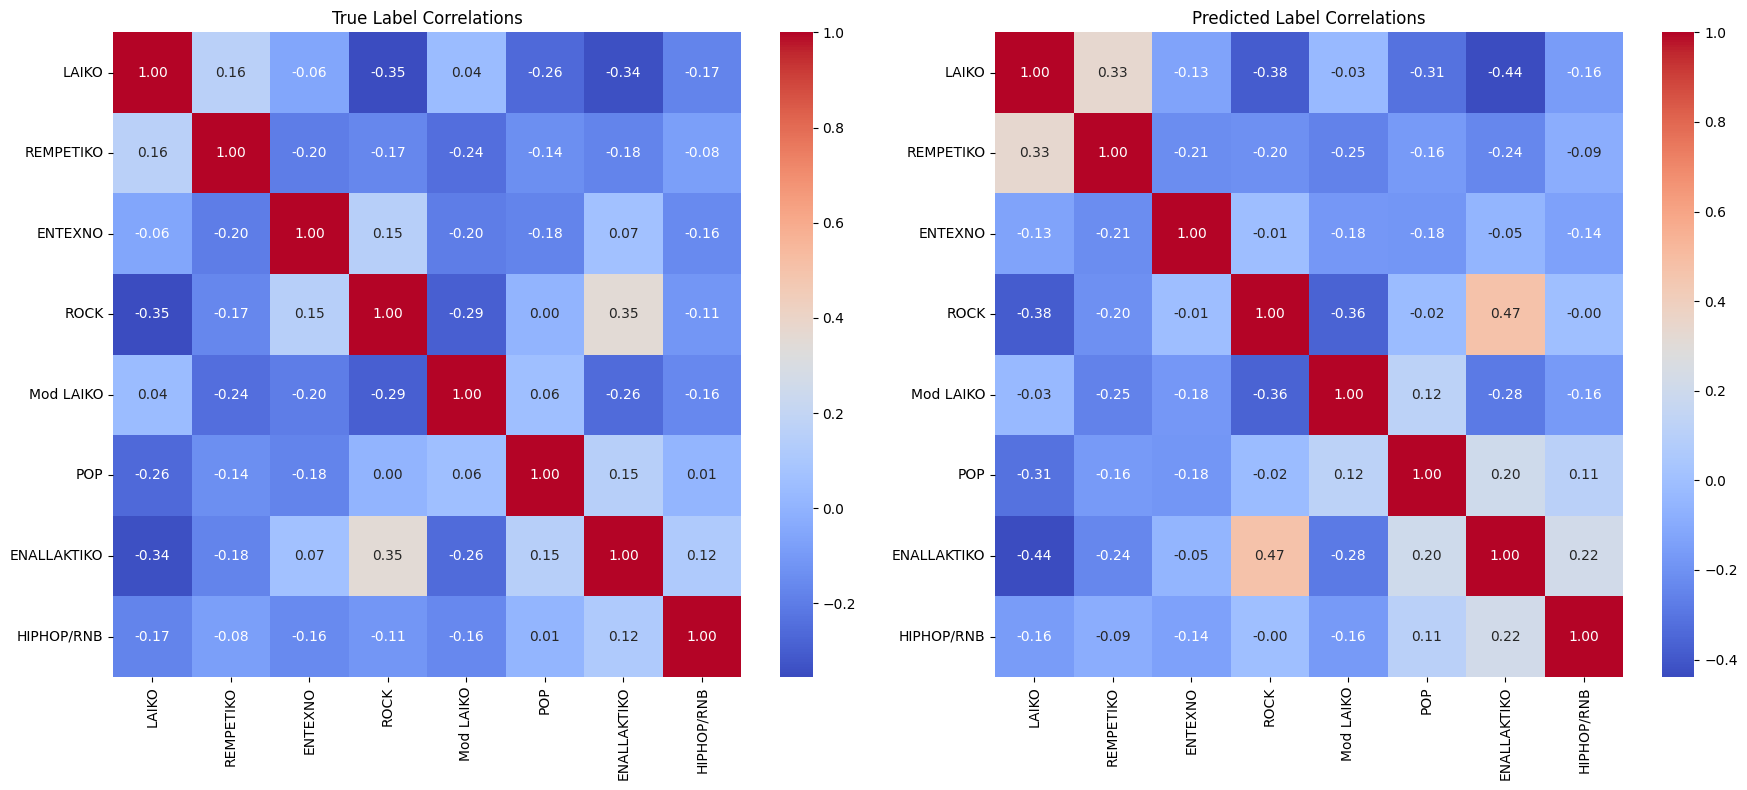

In [59]:
# correlation matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
sns.heatmap(true_corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax1, 
            xticklabels=genre_names, yticklabels=genre_names)
ax1.set_title('True Label Correlations')

sns.heatmap(pred_corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax2, 
            xticklabels=genre_names, yticklabels=genre_names)
ax2.set_title('Predicted Label Correlations')

plt.tight_layout()
plt.show();

In [51]:
# Create a new model that outputs only the dense embeddings
embedding_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer("dense_4").output)

# Get the embeddings
dense_embeddings = embedding_model.predict(test_dataset, batch_size=64)

101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step


/home/georgios/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [52]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Run t-SNE (may take a minute)
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
tsne_results = TSNE(n_components=2, perplexity=30).fit_transform(dense_embeddings)

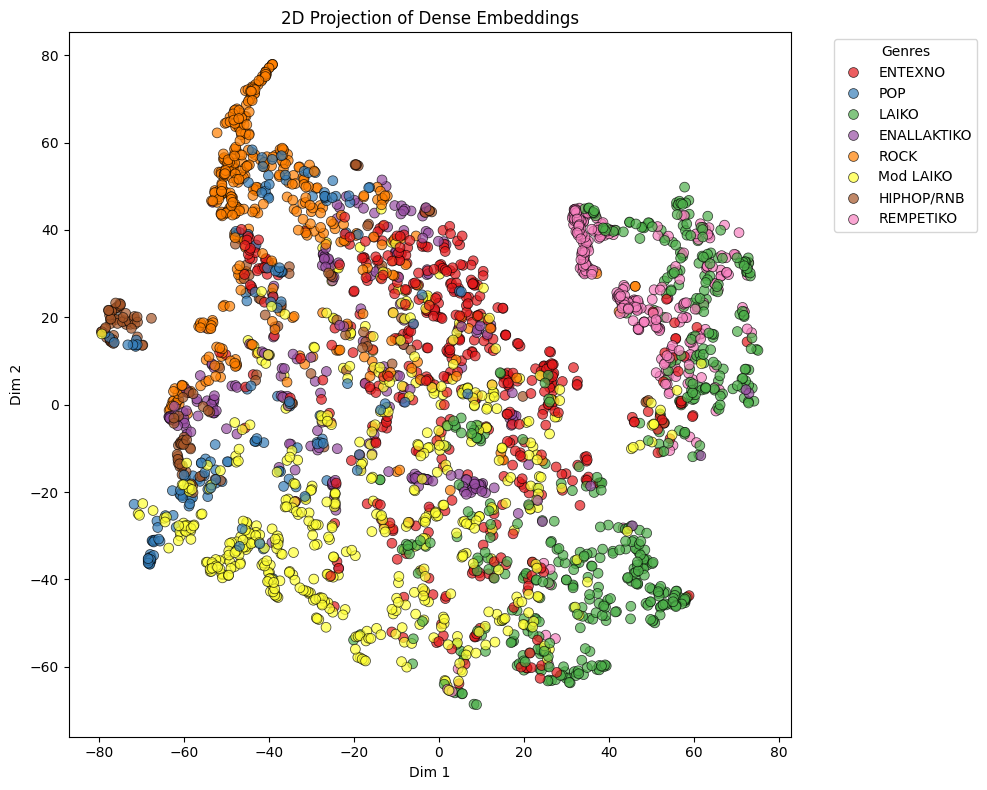

In [59]:
# Get most prominent label for coloring with argmax
single_label_mask = np.sum(y_true, axis=1) == 1
x_embedded_filtered = tsne_results[single_label_mask]
y_labels = np.argmax(y_true[single_label_mask], axis=1)

plt.figure(figsize=(10, 8))
palette = sns.color_palette("hsv", len(np.unique(y_labels)))

genre_names = ['LAIKO', 'REMPETIKO', 'ENTEXNO', 'ROCK', 'Mod LAIKO', 'POP', 'ENALLAKTIKO', 'HIPHOP/RNB']
y_labels_named = [genre_names[i] for i in y_labels]

sns.scatterplot(
    x=x_embedded_filtered[:, 0],
    y=x_embedded_filtered[:, 1],
    hue=y_labels_named,
    palette="Set1",  # updated for better color contrast
    alpha=0.7,
    s=50,
    edgecolor='k'
)


plt.title("2D Projection of Dense Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend(title="Genres", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Explained variance ratio: [0.49380415 0.22049107 0.12472291 0.07292858 0.03693437 0.02347401]


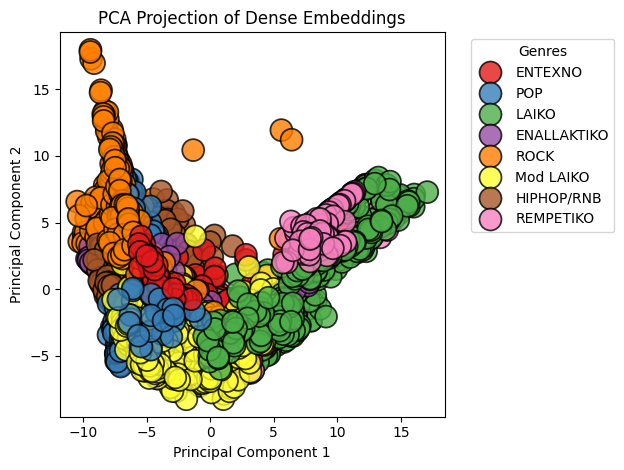

In [60]:
from sklearn.decomposition import PCA

pca = PCA(n_components=6)
pca_results = pca.fit_transform(dense_embeddings)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")  # see how much info is preserved

sns.scatterplot(
    x=pca_results[single_label_mask][:, 0],
    y=pca_results[single_label_mask][:, 1],
    hue=y_labels_named,
    palette="Set1",
    alpha=0.8,
    s=250,
    edgecolor='k'
)
plt.title("PCA Projection of Dense Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Genres", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show();

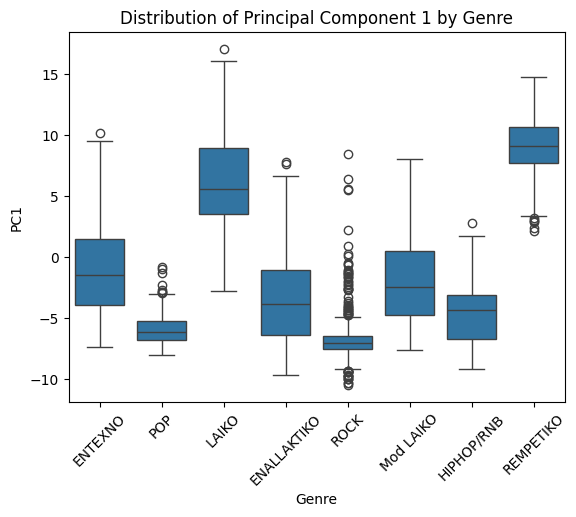

In [61]:
pca_1 = pca_results[single_label_mask][:, 0]

df = pd.DataFrame({
    'PC1': pca_1,
    'Genre': y_labels_named
})

sns.boxplot(data=df, x='Genre', y='PC1')
plt.xticks(rotation=45)
plt.title("Distribution of Principal Component 1 by Genre")
plt.show()